# 7.4 总结：MMoE 与 PLE 多目标

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

读取本章节每个独立算法 Notebook 的实际结果产物，在统一口径下比较和选型。

## Setup

本 Notebook 的默认真实数据是 **Census-Income KDD：MMoE/PLE 论文公开多任务实验的完整官方 train/test**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** MMoE · PLE 原始论文

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "census-income"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'census-income', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 开篇回顾

本章节固定为 **开篇导读 → 独立算法教程 → 结果总结**。每篇算法 Notebook 都包含论文、数学、数据、训练、推理、测试与讨论；本页不重新训练，也不手填数字。

MMoE 为任务选择共享专家；PLE 再隔离任务专属专家。必须逐任务报告，避免平均指标掩盖跷跷板，并检查专家利用率与负迁移。

## 论文关联关系：后一篇在修补前一篇的哪块短板？

两篇论文沿同一条多任务结构线：MMoE 解决“共享底层对任务关系太敏感”，PLE 解决“共享专家仍被无差别共享、跷跷板仍在”。下表中的“交接问题”比发表年份更重要。

In [2]:
import pandas as pd
paper_relationships = pd.DataFrame([{'paper': 'MMoE (2018)', 'starts_from': 'Shared-Bottom 对任务相关性敏感：合成数据上相关性越低，共享底层损失越差（负迁移）', 'user_representation': '任务表示 = 任务专属 gate 对全部共享专家输出的 softmax 加权和', 'training_signal': '逐任务损失的静态加权和 Σλ_k·L_k', 'serving_shape': '一次前向算出所有专家，每任务 gate + tower 输出', 'hands_to_next': '所有专家被所有任务无差别共享；复杂相关任务上仍有跷跷板（PLE 论文测得其 VCR gain 仅 +0.0001）'}, {'paper': 'PLE (2020)', 'starts_from': 'MMoE 共享专家不区分共享/专属知识，工业系统上跷跷板现象仍在', 'user_representation': 'CGC：任务 gate 只读本任务专属专家 + 共享专家；多层渐进分离路由', 'training_signal': '带样本空间掩码的逐任务损失 + 动态损失权重 ω_k,0·γ_k^t', 'serving_shape': '多层专家逐层前向，各任务 tower 输出', 'hands_to_next': '专家数/层数/动态权重超参增多；分层任务组相关性建模仍开放'}])
display(paper_relationships)

,paper,starts_from,user_representation,training_signal,serving_shape,hands_to_next
0,MMoE (2018),Shared-Bottom 对任务相关性敏感：合成数据上相关性越低，共享底层损失越差（负迁移）,任务表示 = 任务专属 gate 对全部共享专家输出的 softmax 加权和,逐任务损失的静态加权和 Σλ_k·L_k,一次前向算出所有专家，每任务 gate + tower 输出,所有专家被所有任务无差别共享；复杂相关任务上仍有跷跷板（PLE 论文测得其 VCR gain...
1,PLE (2020),MMoE 共享专家不区分共享/专属知识，工业系统上跷跷板现象仍在,CGC：任务 gate 只读本任务专属专家 + 共享专家；多层渐进分离路由,"带样本空间掩码的逐任务损失 + 动态损失权重 ω_k,0·γ_k^t",多层专家逐层前向，各任务 tower 输出,专家数/层数/动态权重超参增多；分层任务组相关性建模仍开放


## Results

读取 results 目录。若缺文件，请先按章节顺序执行算法 Notebook。

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
result_dir=ARTIFACT_ROOT/'results'/'chapter_7'; files=sorted(result_dir.glob('*.json'))
assert len(files)==2,f'期望 2 个结果，实际 {[p.name for p in files]}'
records=[]
for path in files: records.extend(json.loads(path.read_text(encoding='utf-8'))['records'])
comparison=pd.DataFrame(records); display(comparison.round(4)); print('数据来源:',[p.name for p in files])

,algorithm,primary_metric,primary_value,secondary_metric,secondary_value,baseline_metric,baseline_value,framework,source_notebook,validation_mode,dataset,randomly_fabricated_rows
0,MMoE 多目标学习,click_auc,0.6263,long_view_auc,0.6221,None,None,torch_rechub.models.multi_task.MMOE,7_2_mmoe,standard,"KuaiRand-Pure (Kuaishou, CIKM 2022)",0
1,PLE 渐进式专家抽取,click_auc,0.6425,long_view_auc,0.6142,None,None,torch_rechub.models.multi_task.PLE,7_3_ple,standard,"KuaiRand-Pure (Kuaishou, CIKM 2022)",0


数据来源: ['7_2_mmoe.json', '7_3_ple.json']


图表字体: Noto Sans CJK JP


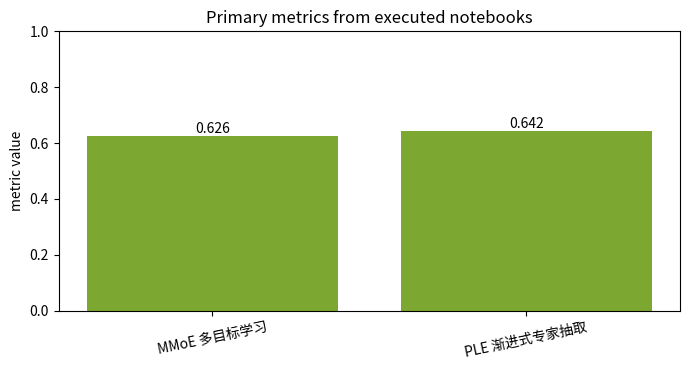

In [4]:
from matplotlib import font_manager

# Matplotlib 默认的 DejaVu Sans 不包含中文字形。优先选择容器中安装的
# Noto CJK；在精简宿主机上找不到中文字体时，退回纯 ASCII 的 Notebook 编号，
# 从根源避免 missing glyph 警告，而不是用 warnings.filterwarnings 隐藏它。
cjk_candidates = ('Noto Sans CJK SC', 'Noto Sans CJK JP', 'Microsoft YaHei', 'SimHei', 'PingFang SC')
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
cjk_font = next((name for name in cjk_candidates if name in installed_fonts), None)
if cjk_font:
    plt.rcParams['font.sans-serif'] = [cjk_font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
chart_labels = comparison.algorithm if cjk_font else comparison.source_notebook
print('图表字体:', cjk_font or 'ASCII fallback（宿主机未安装 CJK 字体）')

fig,ax=plt.subplots(figsize=(max(7,len(comparison)*1.5),3.8))
bars=ax.bar(chart_labels,comparison.primary_value,color='#7ca832')
ax.set(title='Primary metrics from executed notebooks',ylabel='metric value',ylim=(0,max(1.0,comparison.primary_value.max()*1.18)))
ax.tick_params(axis='x',rotation=12)
for bar,value in zip(bars,comparison.primary_value): ax.text(bar.get_x()+bar.get_width()/2,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show()

## 与原论文的可比性审计

下表逐项核对本教程实际产物与论文表格。**“不可直接比较”不是回避差距**：候选集合、样本规模、切分和指标任一不同，数值相减就没有统计含义。这里同时指出当前实验能证明什么、不能证明什么。

In [5]:
paper_audit = pd.DataFrame([{'algorithm': 'MMoE', 'source_notebook': '7_2_mmoe', 'paper_result': 'Census-income 低相关组主任务 AUC best=0.8860、mean=0.8826；Google engagement AUC@6M=0.6908、R²=0.09362', 'paper_protocol': '合成数据 200 次重复控制任务相关性；Census-income 299,285 条、199,523 训练 + 99,762 测试、每法 400 次重复；Google 300 亿隐式反馈训练、100 万留出；线上相对 Shared-Bottom engagement +0.25%、satisfaction +2.65%', 'verdict': 'full 档使用同一 Census-income 官方切分，但目标构造与特征处理为教学复刻，只有完全对齐的字段才可对照；Google 与线上数字为论文系统口径，smoke/KuaiRand 数值不相减。'}, {'algorithm': 'PLE', 'source_notebook': '7_3_ple', 'paper_result': 'VTR AUC=0.6831、VCR MSE=0.1307（双任务 MTL gain 同时为正）；在线总播放量 +4.17%、总观看时长 +3.57%', 'paper_protocol': '腾讯 8 天日志采样：46.926M 用户、2.682M 视频、0.995B 样本，前 7 天训练；4 周在线 A/B 相对单任务模型；公开集 Census-income 0.9522/0.9945、Ali-CCP 0.6112/0.6097', 'verdict': '工业数据与在线数字为腾讯单一系统口径；教程只验证 CGC 结构与逐任务 MTL gain 评估链路，数值不能与论文相减。'}])
live = comparison.copy()
live['tutorial_result'] = live.apply(
    lambda row: f"{row.primary_metric}={row.primary_value:.4f}；{row.secondary_metric}={row.secondary_value:.4f}", axis=1
)
paper_audit = paper_audit.merge(live[['source_notebook', 'tutorial_result']], on='source_notebook', how='left')
display(paper_audit[['algorithm', 'tutorial_result', 'paper_result', 'paper_protocol', 'verdict']])
print('结论：教程数值来自本次 results JSON；smoke/迁移实验不是 paper reproduction。')

,algorithm,tutorial_result,paper_result,paper_protocol,verdict
0,MMoE,click_auc=0.6263；long_view_auc=0.6221,Census-income 低相关组主任务 AUC best=0.8860、mean=0.8...,"合成数据 200 次重复控制任务相关性；Census-income 299,285 条、19...",full 档使用同一 Census-income 官方切分，但目标构造与特征处理为教学复刻，...
1,PLE,click_auc=0.6425；long_view_auc=0.6142,VTR AUC=0.6831、VCR MSE=0.1307（双任务 MTL gain 同时为...,腾讯 8 天日志采样：46.926M 用户、2.682M 视频、0.995B 样本，前 7 ...,工业数据与在线数字为腾讯单一系统口径；教程只验证 CGC 结构与逐任务 MTL gain 评...


结论：教程数值来自本次 results JSON；smoke/迁移实验不是 paper reproduction。


## 未来发展：沿着什么约束继续前进？

未来路线不是一味堆更深网络，而是逐项解除当前系统约束。表格从左到右给出本章已经走过的变化和仍待验证的方向；最后一列是研究/工程问题，不是预告一定会获得线上提升。

In [6]:
future = pd.DataFrame([['共享粒度', '全量共享专家 + 任务 gate', '共享/专属专家显式分离 + 渐进路由', '按样本与任务阶段动态决定共享多少'], ['任务冲突处理', 'gate 权重隐式调节任务差异', '结构性切断其它任务专属专家 + MTL gain 逐任务审计', '任务自动分组、冲突检测与结构搜索'], ['训练信号', '逐任务损失静态加权', '样本空间掩码 + 动态损失权重', '不确定性加权、梯度手术与公平性约束'], ['服务成本', '专家共享一次前向，gate 轻量', '多层专家堆叠，参数与延迟上升', 'top-k 稀疏 gate、专家并行与蒸馏'], ['必须补测', '逐任务指标 + 专家利用率', '跷跷板审计 + 在线 A/B', '长期生态指标、新任务冷启动迁移与 ROI']], columns=['dimension', 'MMoE line', 'PLE line', 'next questions'])
display(future)

,dimension,MMoE line,PLE line,next questions
0,共享粒度,全量共享专家 + 任务 gate,共享/专属专家显式分离 + 渐进路由,按样本与任务阶段动态决定共享多少
1,任务冲突处理,gate 权重隐式调节任务差异,结构性切断其它任务专属专家 + MTL gain 逐任务审计,任务自动分组、冲突检测与结构搜索
2,训练信号,逐任务损失静态加权,样本空间掩码 + 动态损失权重,不确定性加权、梯度手术与公平性约束
3,服务成本,专家共享一次前向，gate 轻量,多层专家堆叠，参数与延迟上升,top-k 稀疏 gate、专家并行与蒸馏
4,必须补测,逐任务指标 + 专家利用率,跷跷板审计 + 在线 A/B,长期生态指标、新任务冷启动迁移与 ROI


## Takeaways

MMoE 为任务选择共享专家；PLE 再隔离任务专属专家。必须逐任务报告，避免平均指标掩盖跷跷板，并检查专家利用率与负迁移。

先固定业务阶段和候选口径，再比较主指标、辅助指标、baseline 与系统成本。smoke 数值用于代码回归和学习，不能跨数据或跨公司宣称优劣。

## Checks

In [7]:
assert len(comparison)==2
assert comparison.source_notebook.nunique()==2
assert comparison.primary_value.between(0,1).all()
print('PASS：总结完全来自独立 Notebook 的执行产物。')

PASS：总结完全来自独立 Notebook 的执行产物。


## Next Steps

在相同完整数据、时间切分、负样本和候选集上重跑；加入效果—延迟—成本三维表，再决定是否进入线上 A/B。